In [6]:
include("QFactor.jl")
using Plots
using ProgressMeter

### Basic usage

For basic usage, simply call the qfactor function.
The default values should be good to achieve convergent results for driving frequencies below wM<1
```
qfactor(w; rmin, rmax, solver_lin, solver_scd, oo, atol, rtol) > ComplexF64 (Q factor)
w: the driving frequency
rmin=R: parameter such that the minimum radius of integration is 2M+10^(-R)
rmax=10^5/w: maximum radius of integration
solver_lin="default": Solver to use for the integration of the linear homogeneous equation
solver_scd="verne": Solver to use for the integration of the second-order homogeneous equation
oo=12: Order of the Gauss-Kronrod quadrature
atol=1e-7: Absolute tolerance 
rtol=1e-7: Relative tolerance
```

Typically one only needs to modify rmin and rmax, depending on available compute time or driving frequency. 
At high frequencies, solver_lin="verne" may lead to more stable results

In [2]:
qfactor(0.2)

-0.004491138716439511 - 0.0046510356292566455im

### |Q| vs omega

In [3]:
ω_vals = collect(0.05:0.01:0.8)
q_vals = zeros(length(ω_vals))

@showprogress for (j,w) in enumerate(ω_vals)
    if w < 0.3
        Λ = 4.0
    elseif w < 0.6
        Λ = 5.0
    else 
        Λ = 6.0
    end
    q_vals[j] = abs(qfactor(w, Λ+1, 10^(Λ-1)/w, "verne", "verne", 12, 1e-7,1e-7))
end

Progress: 100%|█████████████████████████████████████████| Time: 0:01:39


In [4]:
open("../data/q_vals.dat", "w") do io 
    println(io,"w q")
    for (w,q) in zip(ω_vals, q_vals)
        println(io,"$(w) $(q)")
    end
end

In [3]:
ω_vals = collect(0.05:0.01:1.0)
q3_vals = zeros(length(ω_vals))

@showprogress for (j,w) in enumerate(ω_vals)
    if w < 0.3
        Λ = 4.0
    elseif w < 0.6
        Λ = 5.0
    else 
        Λ = 6.0
    end
    q3_vals[j] = abs(qfactor3(w, Λ+1, 10^(Λ-1)/w, "verne", "verne", 12, 1e-7,1e-7))
end

Progress: 100%|█████████████████████████████████████████| Time: 0:01:11


In [4]:
open("../data/q3_vals.dat", "w") do io 
    println(io,"w q")
    for (w,q) in zip(ω_vals, q3_vals)
        println(io,"$(w) $(q)")
    end
end

In [16]:
ω_vals = collect(0.05:0.01:1.0)
q4_vals = zeros(length(ω_vals))

@showprogress for (j,w) in enumerate(ω_vals)
    if w < 0.3
        Λ = 4.0
    elseif w < 0.6
        Λ = 5.0
    else 
        Λ = 6.0
    end
    q4_vals[j] = abs(qfactor4(w, Λ+1, 10^(Λ-1)/w, "verne", "verne", 12, 1e-7,1e-7))
end

Progress: 100%|█████████████████████████████████████████| Time: 0:03:00


In [17]:
open("../data/q4_vals.dat", "w") do io 
    println(io,"w q")
    for (w,q) in zip(ω_vals, q4_vals)
        println(io,"$(w) $(q)")
    end
end

### Convergence of |Q| 

l_vals = collect(3.0:0.1:6.0)
ω_vals = collect(0.1:0.1:0.81)
q_vals = zeros((length(ω_vals), length(l_vals)))

@showprogress for (i,Λ) in enumerate(l_vals)
    for (j,w) in enumerate(ω_vals)
        qf = abs(qfactor(w, Λ+1, 10^(Λ-1)/w, "verne", "verne"))
        q_vals[j,i]=qf
    end
end

In [5]:
l_vals = collect(3.0:0.1:6.0)
ω_vals = collect(0.1:0.1:0.81)
q_vals = zeros((length(ω_vals), length(l_vals)))

@showprogress for (i,Λ) in enumerate(l_vals)
    for (j,w) in enumerate(ω_vals)
        qf = abs(qfactor(w, Λ+1, 10^(Λ-1)/w, "verne", "verne"))
        q_vals[j,i]=qf
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:04:21


In [7]:
open("../data/convergence.dat", "w") do IO
    write(IO,"lambda w1 w2 w3 w4 w5 w6 w7 w8 \n")
    for (i,l) in enumerate(l_vals)
        write(IO, "$(l) $(q_vals[1,i]) $(q_vals[2,i]) $(q_vals[3,i]) $(q_vals[4,i]) $(q_vals[5,i]) $(q_vals[6,i]) $(q_vals[7,i]) $(q_vals[8,i])\n")
    end
end

In [5]:
l_vals = collect(3.0:0.1:6.0)
ω_vals = collect(0.1:0.15:1.01)
q3_vals = zeros((length(ω_vals), length(l_vals)))

@showprogress for (i,Λ) in enumerate(l_vals)
    for (j,w) in enumerate(ω_vals)
        qf = abs(qfactor3(w, Λ+1, 10^(Λ-1)/w, "verne", "verne"))
        q3_vals[j,i]=qf
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:01:05


In [ ]:
open("../data/convergence_3.dat", "w") do IO
    write(IO,"lambda w1 w2 w3 w4 w5 w6 w7 w8 \n")
    for (i,l) in enumerate(l_vals)
        write(IO, "$(l) $(q3_vals[1,i]) $(q3_vals[2,i]) $(q_vals[3,i]) $(q_vals[4,i]) $(q_vals[5,i]) $(q_vals[6,i]) $(q_vals[7,i]) $(q_vals[8,i])\n")
    end
end

### Asymptotics of the Source Term

In [8]:
ω = 0.1
rmin = 6.0
rmax = 1000.0

sol1 = linear_sol(2, ω, "odd", rmin, rmax)

aux = collect(-6.0:0.01:3.0)
r_vals = @. 2.0 + 10^aux
reg_src = zeros(length(r_vals))
bad_src = zeros(length(r_vals))

for (i,r) in enumerate(r_vals)
    reg_src[i] = abs.(SOOE(sol1, ω, r))
    bad_src[i] = abs.(NONREGSOURCE(sol1, ω, r))
end

In [9]:
function rs(r)
    return @. r+2*log(r/2-1)
end

rs_vals = rs(r_vals)

open("../data/source.dat", "w") do IO
    write(IO,"rs sreg sbad close far\n")
    for (r,rt,s,sb) in zip(r_vals,rs_vals, reg_src, bad_src)
        fitfar = 1e4/r^2
        write(IO,"$(rt) $(s) $(sb) $(0.02*(r-2)) $(fitfar)\n")
    end
end

### Low wM

In [7]:
aux = collect(-4:0.1:-1)
ω_vals = @. 10.0^aux 
q_vals = zeros(length(ω_vals))
Λ=4.0

@showprogress for (j,w) in enumerate(ω_vals)
    q_vals[j] = abs(qfactor(w, Λ+1, 10^(Λ-1)/w, "default", "verne", 12, 1e-7,1e-7))
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:08


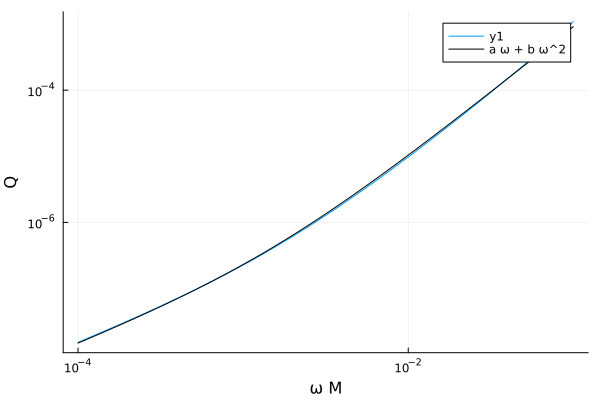

In [31]:
plot(ω_vals, q_vals, xscale=:log10, yscale=:log10)
xlabel!("ω M")
ylabel!("Q")
fit=@. (1.4e-4* ω_vals + 0.9e-1* ω_vals^2)
plot!(ω_vals, fit, color=:black, label="a ω + b ω^2")